In [1]:
import torch
import random
import numpy as np
import matplotlib.pyplot as plt

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
words = open("names.txt", "r").read().splitlines()

In [4]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [5]:
vocab_size = len(stoi)

In [63]:
block_size = 3

def prepare_data(words):
    X,Y = [], []
    for word in words:
        context = [0] * block_size
        for char in word:
            X.append(context)
            Y.append(stoi[char])

            context = context[1:] + [stoi[char]]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

random.seed(47)
random.shuffle(words)
n1 = int(0.8 * len(words))

Xtr, Ytr = prepare_data(words[:n1])
Xtes, Ytes = prepare_data(words[n1:])

In [64]:
Xtr[0], Ytr[0]

(tensor([0, 0, 0]), tensor(2))

In [83]:
emb_dim = 3
n1 = 100
n2 = 27

epochs = 100000
batch_size = 32
lr = 0.1

In [84]:
C = torch.randn(vocab_size, emb_dim)

#layer_1
w1 = torch.randn(block_size * emb_dim, n1)
b1 = torch.randn(n1)

#layer_2
w2 = torch.randn(n1, n2)
b2 = torch.randn(n2)

parameters = [C, w1, b1, w2, b2]

for p in parameters:
    p.requires_grad = True

In [ ]:
lossies = []
for epoch in range(epochs):

    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    # print(ix.shape)
    x,y = Xtr[ix], Ytr[ix]

    #lookup
    emb = C[x]
    # print(emb.shape)
    formatted_input = emb.view(emb.shape[0], emb.shape[1]*emb.shape[2])
    # print(formatted_input)

    #layer_1
    h = formatted_input @ w1 + b1
    h = torch.tanh(h)

    #layer_2
    logits = h @ w2 + b2

    #softmax
    logit_max = logits.max()
    logits = logits - logit_max
    logits_exp = logits.exp()
    logits_exp_sum = logits_exp.sum()
    probs = logits_exp/logits_exp_sum

    #loss
    # print(y)
    loss = -probs[torch.arange(batch_size), y].log().mean()
    lossies.append(loss.item())
    
    #update_grad
    for p in parameters:
        p.grad = None
    
    #backward_prop
    loss.backward()

    #update parameters
    for p in parameters:
        p.data += -lr * p.grad


In [ ]:
lossies

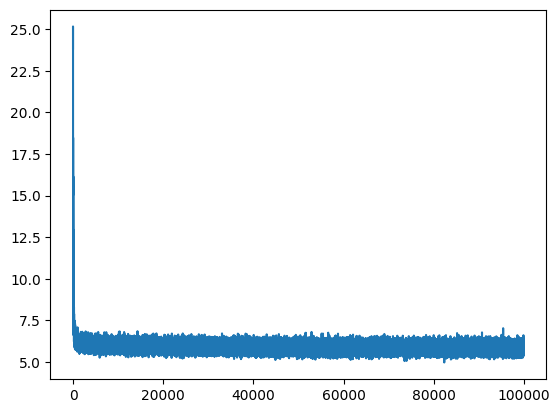

In [86]:
plt.plot(torch.arange(epochs), lossies)